In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

conn = sqlite3.connect("saas_data.db")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

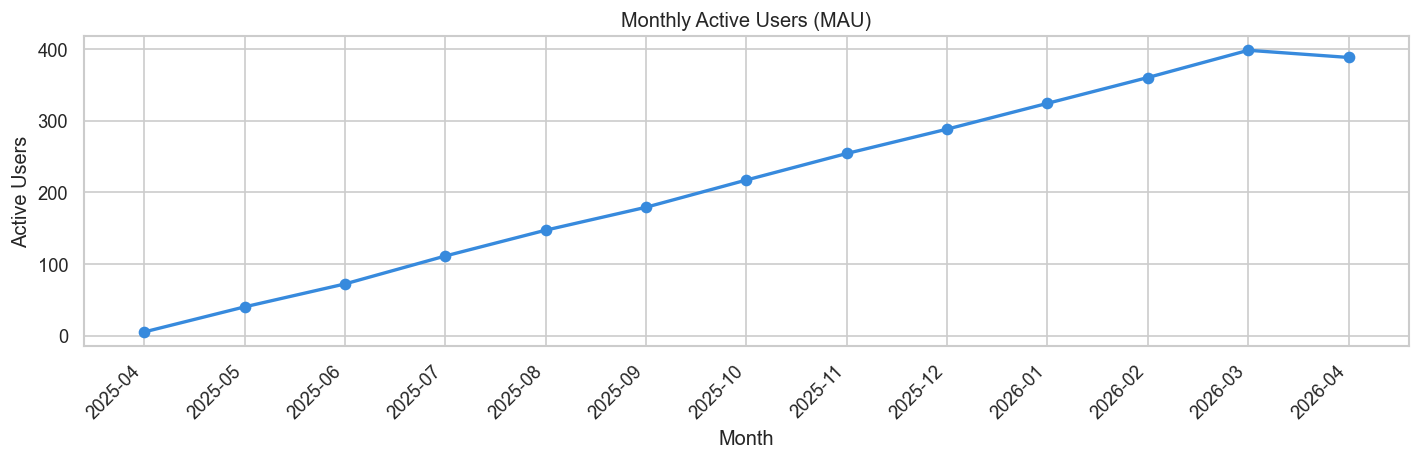

In [3]:
#Chart 1 — Monthly Active Users (MAU) Trend

mau = pd.read_sql("""
    SELECT strftime('%Y-%m', event_date) AS month,
           COUNT(DISTINCT user_id) AS active_users
    FROM events GROUP BY month ORDER BY month
""", conn)

plt.figure(figsize=(12, 4))
plt.plot(mau["month"], mau["active_users"], marker="o", color="#378ADD", linewidth=2)
plt.xticks(rotation=45, ha="right")
plt.title("Monthly Active Users (MAU)")
plt.xlabel("Month")
plt.ylabel("Active Users")
plt.tight_layout()
plt.savefig("chart_mau.png")
plt.show()

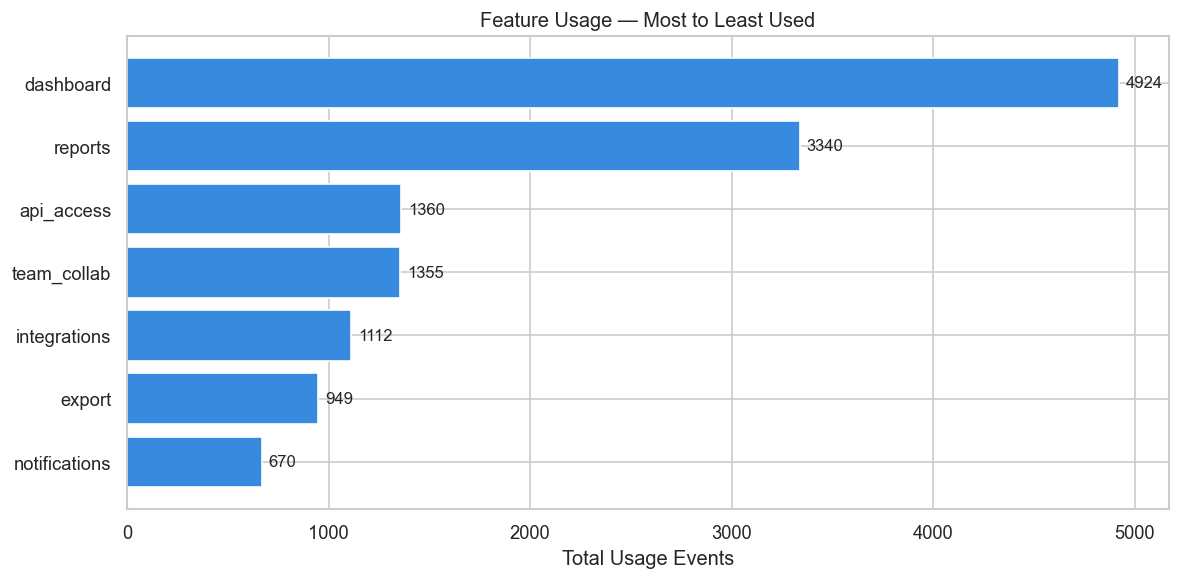

In [4]:
#Chart 2 — Feature Usage Bar Chart

features = pd.read_sql("""
    SELECT feature, COUNT(*) AS total_usage,
           COUNT(DISTINCT user_id) AS unique_users
    FROM events GROUP BY feature ORDER BY total_usage DESC
""", conn)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(features["feature"], features["total_usage"], color="#378ADD")
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel("Total Usage Events")
ax.set_title("Feature Usage — Most to Least Used")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("chart_features.png")
plt.show()

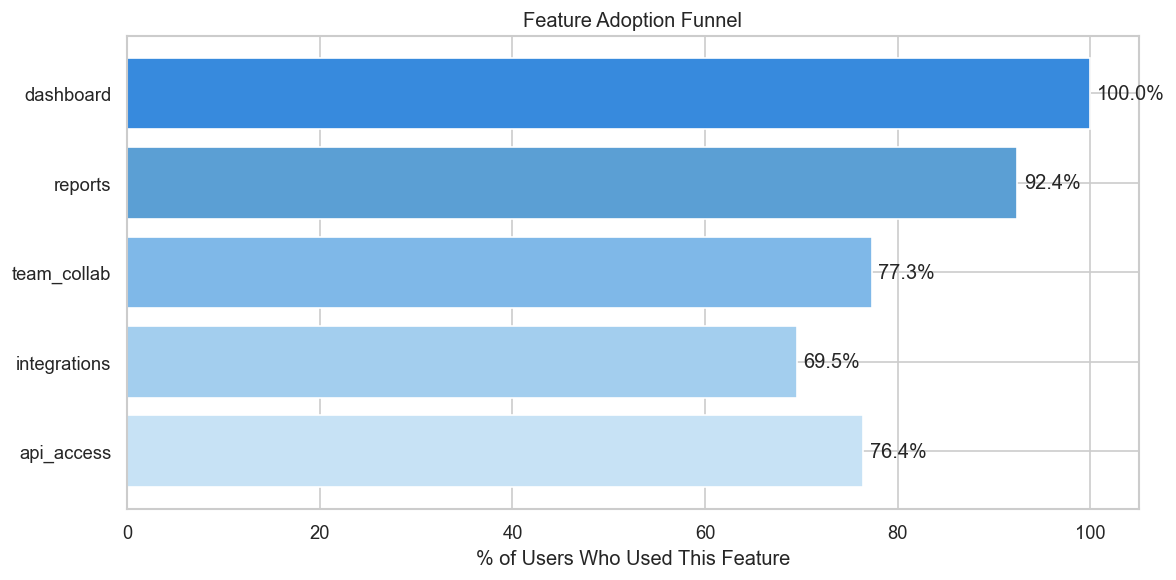

In [5]:
#Chart 3 — Feature Adoption Funnel

funnel_features = ["dashboard", "reports", "team_collab", "integrations", "api_access"]

funnel_data = pd.read_sql("""
    SELECT feature, COUNT(DISTINCT user_id) AS users
    FROM events WHERE feature IN ({})
    GROUP BY feature
""".format(",".join(f"'{f}'" for f in funnel_features)), conn)

# Sort by our defined funnel order
funnel_data["order"] = funnel_data["feature"].map({f: i for i, f in enumerate(funnel_features)})
funnel_data = funnel_data.sort_values("order")
total = funnel_data["users"].iloc[0]
funnel_data["pct"] = (funnel_data["users"] / total * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#378ADD", "#5B9FD4", "#7FB8E8", "#A3CEEE", "#C7E2F5"]
bars = ax.barh(funnel_data["feature"], funnel_data["pct"], color=colors)
ax.bar_label(bars, labels=[f'{v}%' for v in funnel_data["pct"]], padding=4)
ax.set_xlabel("% of Users Who Used This Feature")
ax.set_title("Feature Adoption Funnel")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("chart_funnel.png")
plt.show()

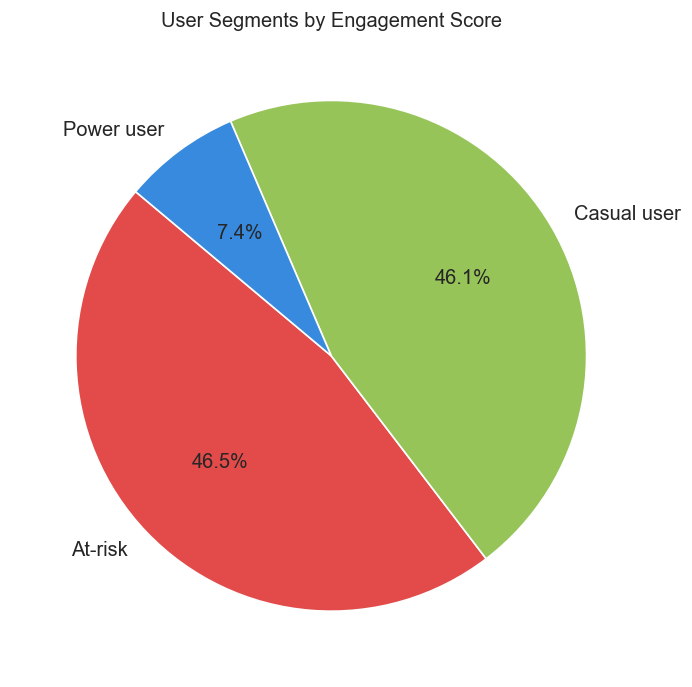

In [6]:
#Chart 4 — User Segmentation by Engagement Score

# Calculate engagement score per user
event_counts = pd.read_sql("""
    SELECT user_id, COUNT(*) AS total_events,
           COUNT(DISTINCT feature) AS unique_features
    FROM events GROUP BY user_id
""", conn)

event_counts["engagement_score"] = (
    event_counts["total_events"] * 0.6 +
    event_counts["unique_features"] * 10 * 0.4
).round(1)

# Segment users
def segment(score):
    if score >= 80:   return "Power user"
    elif score >= 30: return "Casual user"
    else:             return "At-risk"

event_counts["segment"] = event_counts["engagement_score"].apply(segment)
seg_counts = event_counts["segment"].value_counts()

colors = {"Power user": "#378ADD", "Casual user": "#97C459", "At-risk": "#E24B4A"}
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(seg_counts, labels=seg_counts.index, autopct="%1.1f%%",
       colors=[colors[s] for s in seg_counts.index],
       startangle=140, textprops={"fontsize": 12})
ax.set_title("User Segments by Engagement Score")
plt.tight_layout()
plt.savefig("chart_segments.png")
plt.show()

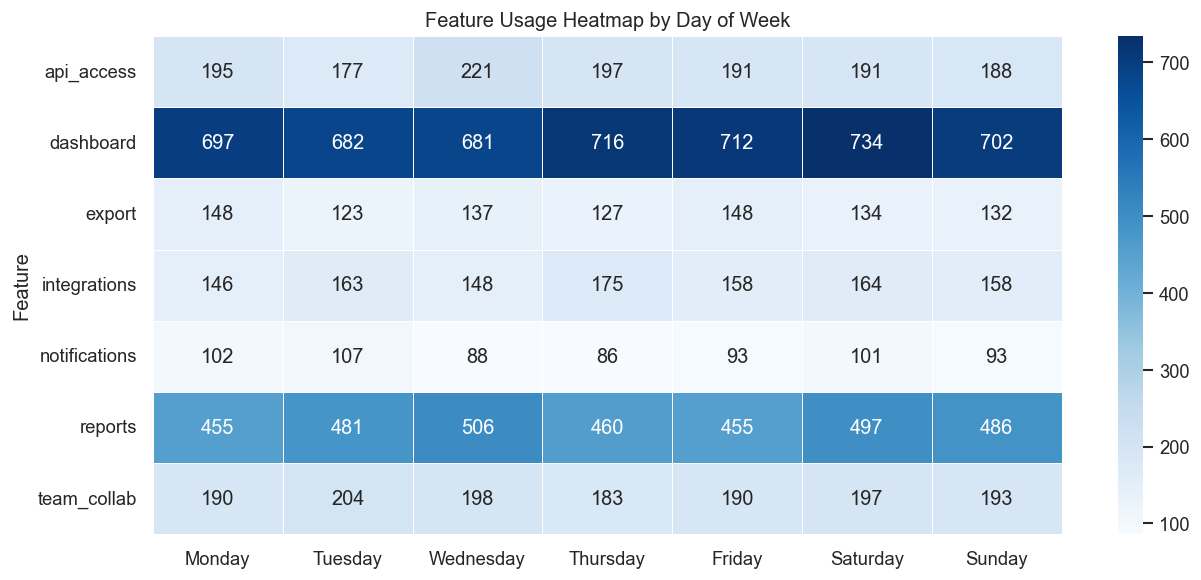

In [7]:
#Chart 5 — Feature Heatmap (Usage by Day of Week)

events_df = pd.read_sql("SELECT * FROM events", conn)
events_df["event_date"] = pd.to_datetime(events_df["event_date"])
events_df["day_of_week"] = events_df["event_date"].dt.day_name()

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
heatmap_data = events_df.groupby(["feature","day_of_week"]).size().unstack()
heatmap_data = heatmap_data[day_order]

plt.figure(figsize=(11, 5))
sns.heatmap(heatmap_data, cmap="Blues", annot=True, fmt="d", linewidths=0.5)
plt.title("Feature Usage Heatmap by Day of Week")
plt.ylabel("Feature")
plt.xlabel("")
plt.tight_layout()
plt.savefig("chart_heatmap.png")
plt.show()